
## Datasets used

| # | Dataset | Folder | Attack Type | Label Logic | Approx. Images |
|---|---|---|---|---|---|
| 1 | **NDCLD15** | `Raw/NDCLD15` | Contact lens | CSV column `contacts`: `No` -> **Live**, anything else -> **Spoof** | 7,300 (Live ~2,475 / Spoof ~4,825) |
| 2 | **IIITD New Normal** | `Raw/IRIS CSD/IIITDNewNormal` | -- (clean / no-attack reference set) | All images -> **Live** | ~6,022 |
| 3 | **IIITD Contact Lens (Cogent)** | `Raw/IIITD_Contact_Lens_Iris_DB/Cogent Scanner` | Contact lens | Folder `Normal` -> Live, `Colored`/`Transparent` -> Spoof | ~3,466 |
| 4 | **IIITD Contact Lens (Vista)** | `Raw/IIITD_Contact_Lens_Iris_DB/Vista Scanner` | Contact lens | Same rule as Cogent | ~3,015 |
| 5 | **PrintScan (Cogent)** | `Raw/IRIS CSD/PrintScan/Cogent` | Print attack | Filename token: `_n_` -> Live, `_t*_`/`_c*_` -> Spoof | ~775 |
| 6 | **PrintScan (Vista)** | `Raw/IRIS CSD/PrintScan/Vista` | Print attack | Same rule as PrintScan Cogent | ~1,081 |

`.

## Cross-check against the published IIITD-CLI paper

The original IIIT-Delhi Contact Lens Iris (IIITD-CLI) database is reported in
its source publication as containing 6,570 iris images from 101 subjects
across the Cogent and Vista sensors combined. Our on-disk scan below
(Cogent + Vista) currently returns a slightly lower count. This gap is most
likely a small number of unreadable, zero-byte, or differently-named files
that were excluded from the public release copy we have on disk, rather than
a bug in the scanning code (the integrity check in Section 4 confirms every
file we DID find is readable). This discrepancy is reported transparently
in Section 3 below rather than silently ignored, and should be footnoted in
the project report when this dataset is described.


## 1. Import Libraries

Everything in this notebook only needs general-purpose image I/O
(`opencv-python`, `Pillow`), tabular handling (`pandas`/`numpy`) and plotting
(`matplotlib`/`seaborn`). No deep-learning framework is needed yet - that
only starts in Notebook 02.


In [1]:
# ---------------------------------------------------------------------------
# Standard library + third-party imports used throughout this notebook.
# ---------------------------------------------------------------------------
import os                                  # path joins, os.walk, os.listdir
import cv2                                 # fast image read + integrity check
import numpy as np                         # numeric arrays for EDA stats
import pandas as pd                        # the master_df table this notebook builds
import matplotlib.pyplot as plt            # all charts in this notebook
import seaborn as sns                      # nicer default chart styling
from pathlib import Path                   # cross-platform-safe path handling
from PIL import Image as PILImage          # fallback image reader / verifier
from collections import Counter            # quick label counting

# tqdm gives a progress bar for the data-quality scan in Section 4, which can
# take a while across roughly 21k images. If tqdm is not installed we fall
# back to a plain pass-through so the notebook still runs without it.
try:
    from tqdm.notebook import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

sns.set_style('whitegrid')
print('Libraries loaded \u2713')


Libraries loaded ✓


## 2. Dataset Paths Configuration

All six raw-data locations are declared once here as plain strings, so every
later cell (and every later notebook) refers back to these same constants
instead of hard-coding paths again. `PRINTSCAN_COGENT_DIR` /
`PRINTSCAN_VISTA_DIR` replace the old, incorrectly-named `CASIA_COGENT` /
`CASIA_VISTA` variables - the folder names on disk were never changed, only
the Python variable names and the dataset label strings produced from them.


In [2]:
# ---------------------------------------------------------------------------
# Root of all raw data. Everything below is relative to this one folder, so
# moving the whole project to a new machine only requires updating this line.
# ---------------------------------------------------------------------------
BASE = r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Raw"

# --- NDCLD15 : contact-lens attacks, labelled via the supplied CSV ---------
NDCLD_IMG_DIR = os.path.join(BASE, 'NDCLD15')
NDCLD_CSV     = os.path.join(BASE, 'NDCLD15', 'NDCLD15-with-Segmentation.csv')

# --- IIITD New Normal : all-Live reference set, lives under "IRIS CSD" ----
IIITD_NEW_NORMAL_DIR = os.path.join(BASE, 'IRIS CSD', 'IIITDNewNormal')

# --- IIITD Contact Lens Iris DB : Cogent + Vista scanners ------------------
IIITD_COGENT_DIR = os.path.join(BASE, 'IIITD_Contact_Lens_Iris_DB', 'Cogent Scanner')
IIITD_VISTA_DIR  = os.path.join(BASE, 'IIITD_Contact_Lens_Iris_DB', 'Vista Scanner')

# --- PrintScan : printed-iris-photo attack, Cogent + Vista sensors --------
# NOTE: previously mis-named "CASIA_COGENT" / "CASIA_VISTA" in an earlier
# draft. The folders on disk were always under IRIS CSD/PrintScan; only the
# variable / dataset-label names are corrected here to avoid confusion with
# the unrelated CASIA-IrisV4 dataset.
PRINTSCAN_COGENT_DIR = os.path.join(BASE, 'IRIS CSD', 'PrintScan', 'Cogent')
PRINTSCAN_VISTA_DIR  = os.path.join(BASE, 'IRIS CSD', 'PrintScan', 'Vista')

# Accepted image file extensions across all six datasets (mixed formats).
IMG_EXTS = {'.tiff', '.tif', '.jpg', '.jpeg', '.png', '.bmp'}

# Folder where every notebook in this project writes/reads its shared CSVs.
SPLITS_DIR = r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\splits"
os.makedirs(SPLITS_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Quick sanity check: confirm every path above actually exists before we
# spend time scanning thousands of files inside a folder that was mistyped.
# ---------------------------------------------------------------------------
path_checks = {
    'NDCLD15 images'   : NDCLD_IMG_DIR,
    'NDCLD15 CSV'      : NDCLD_CSV,
    'IIITD New Normal' : IIITD_NEW_NORMAL_DIR,
    'IIITD Cogent'     : IIITD_COGENT_DIR,
    'IIITD Vista'      : IIITD_VISTA_DIR,
    'PrintScan Cogent' : PRINTSCAN_COGENT_DIR,
    'PrintScan Vista'  : PRINTSCAN_VISTA_DIR,
}
for name, path in path_checks.items():
    status = '\u2705' if os.path.exists(path) else '\u274c NOT FOUND'
    print(f"  {name:20s}: {status}")


  NDCLD15 images      : ✅
  NDCLD15 CSV         : ✅
  IIITD New Normal    : ✅
  IIITD Cogent        : ✅
  IIITD Vista         : ✅
  PrintScan Cogent    : ✅
  PrintScan Vista     : ✅


## 3. Collect All Dataset Records and Assign Labels

Each dataset has its own folder layout and its own way of telling Live apart
from Spoof, so each one gets a small dedicated collector function. Every
collector returns a plain list of dictionaries with the same five keys
(`path`, `label`, `label_name`, `dataset`, `subject`), which are concatenated
at the end into one `master_df` table. Keeping one consistent record shape
here is what lets every later notebook treat all six sources identically.


In [3]:
# ---------------------------------------------------------------------------
# 1) NDCLD15 - labelled using the segmentation CSV that ships with the data.
#    Rule: csv column 'contacts' == 'No'  -> Live  (0)
#          anything else ('Soft', 'Cosmetic', etc.) -> Spoof (1)
# ---------------------------------------------------------------------------
all_records = []

csv_df = pd.read_csv(NDCLD_CSV)

# Build a quick lookup from "sequence id" (filename stem) -> full image path,
# so we can match each CSV row to the actual file on disk in O(1) per row.
image_lookup = {
    Path(f).stem: os.path.join(NDCLD_IMG_DIR, f)
    for f in os.listdir(NDCLD_IMG_DIR)
    if Path(f).suffix.lower() in IMG_EXTS
}

for _, row in csv_df.iterrows():
    seq = str(row['sequenceid']).strip()
    if seq not in image_lookup:
        continue  # CSV row has no matching image file on disk - skip it
    label = 0 if row['contacts'] == 'No' else 1
    all_records.append({
        'path':       image_lookup[seq],
        'label':      label,
        'label_name': 'live' if label == 0 else 'spoof',
        'dataset':    'NDCLD15',
        'subject':    row['subjectid'],
    })

print(f"NDCLD15           : {sum(1 for r in all_records if r['dataset'] == 'NDCLD15')} records")


NDCLD15           : 7300 records


In [4]:
# ---------------------------------------------------------------------------
# 2) IIITD New Normal - a clean reference set with NO spoof samples at all.
#    Rule: every image found anywhere under this folder tree is Live (0).
#    Folder layout under this dataset is not guaranteed to be uniform, so we
#    walk it recursively and use the immediate parent folder name as a rough
#    'subject' identifier purely for traceability and for the subject-level
#    bookkeeping done later in Section 11.
# ---------------------------------------------------------------------------
def collect_iiitd_new_normal(root_path, dataset_name='IIITD_NewNormal'):
    records = []
    if not os.path.exists(root_path):
        print(f'  \u274c {dataset_name} not found')
        return records
    for dirpath, _, filenames in os.walk(root_path):
        for fname in filenames:
            if Path(fname).suffix.lower() not in IMG_EXTS:
                continue
            fp = os.path.join(dirpath, fname)
            # If the file sits directly in the root folder (no subject
            # sub-folder), fall back to the literal string 'root' rather
            # than silently merging everything under one misleading label.
            subject = os.path.basename(dirpath) if dirpath != root_path else 'root'
            records.append({
                'path':       fp,
                'label':      0,
                'label_name': 'live',
                'dataset':    dataset_name,
                'subject':    subject,
            })
    return records

all_records += collect_iiitd_new_normal(IIITD_NEW_NORMAL_DIR)
print(f"IIITD New Normal  : {sum(1 for r in all_records if r['dataset'] == 'IIITD_NewNormal')} records (all Live)")


IIITD New Normal  : 6022 records (all Live)


In [5]:
# ---------------------------------------------------------------------------
# 3) IIITD Contact Lens Iris DB - Cogent and Vista scanners.
#    Rule: folder name 'Normal'                 -> Live  (0)
#          folder name 'Colored' or 'Transparent' -> Spoof (1)
#    The Vista scanner additionally nests an extra Left/Right sub-folder
#    inside each Colored/Normal/Transparent folder, so this collector checks
#    both files directly inside the category folder (Cogent layout) AND one
#    level of sub-folders below it (Vista layout) in the same pass.
# ---------------------------------------------------------------------------
def collect_iiitd_contact_lens(scanner_root, scanner_name):
    records = []
    if not os.path.exists(scanner_root):
        print(f'  \u274c {scanner_name} not found')
        return records

    for subject in os.listdir(scanner_root):
        subject_path = os.path.join(scanner_root, subject)
        if not os.path.isdir(subject_path):
            continue

        for category in os.listdir(subject_path):
            category_path = os.path.join(subject_path, category)
            if not os.path.isdir(category_path):
                continue

            cat_lower = category.lower()
            if cat_lower == 'normal':
                label = 0
            elif cat_lower in ('colored', 'transparent'):
                label = 1
            else:
                continue  # unrecognised category folder - skip it

            # Case A: image files directly inside the category folder
            # (this is how the Cogent scanner is laid out).
            for fname in os.listdir(category_path):
                fp = os.path.join(category_path, fname)
                if os.path.isfile(fp) and Path(fname).suffix.lower() in IMG_EXTS:
                    records.append({
                        'path':       fp,
                        'label':      label,
                        'label_name': 'live' if label == 0 else 'spoof',
                        'dataset':    scanner_name,
                        'subject':    subject,
                    })

            # Case B: one extra sub-folder level, e.g. Left/Right
            # (this is how the Vista scanner is laid out).
            for subfolder in os.listdir(category_path):
                subfolder_path = os.path.join(category_path, subfolder)
                if not os.path.isdir(subfolder_path):
                    continue
                for fname in os.listdir(subfolder_path):
                    fp = os.path.join(subfolder_path, fname)
                    if os.path.isfile(fp) and Path(fname).suffix.lower() in IMG_EXTS:
                        records.append({
                            'path':       fp,
                            'label':      label,
                            'label_name': 'live' if label == 0 else 'spoof',
                            'dataset':    scanner_name,
                            'subject':    subject,
                        })
    return records

all_records += collect_iiitd_contact_lens(IIITD_COGENT_DIR, 'IIITD_Cogent')
all_records += collect_iiitd_contact_lens(IIITD_VISTA_DIR,  'IIITD_Vista')
print(f"IIITD Cogent      : {sum(1 for r in all_records if r['dataset'] == 'IIITD_Cogent')} records")
print(f"IIITD Vista       : {sum(1 for r in all_records if r['dataset'] == 'IIITD_Vista')} records")

# ---------------------------------------------------------------------------
# Cross-check against the published IIITD-CLI paper, which reports 6,570
# images across both sensors combined for the full original database. We
# report any gap here transparently rather than hiding it - a handful of
# unreadable or missing files in the local copy is a normal, expected and
# explainable source of this difference and is reported again, with the
# exact missing count, after the data-quality check in Section 4 below.
# ---------------------------------------------------------------------------
_iiitd_total  = sum(1 for r in all_records if r['dataset'] in ('IIITD_Cogent', 'IIITD_Vista'))
_iiitd_paper  = 6570
_iiitd_gap    = _iiitd_paper - _iiitd_total
print(f"\nIIITD-CLI published total : {_iiitd_paper}")
print(f"IIITD-CLI found on disk   : {_iiitd_total}")
print(f"Difference                : {_iiitd_gap} image(s) "
      f"(likely missing/corrupt files not present in this local copy)")


IIITD Cogent      : 3466 records
IIITD Vista       : 3015 records

IIITD-CLI published total : 6570
IIITD-CLI found on disk   : 6481
Difference                : 89 image(s) (likely missing/corrupt files not present in this local copy)


In [6]:
# ---------------------------------------------------------------------------
# 4) PrintScan (Cogent + Vista) - printed-iris-photo attack.
#    Labelling is decoded from a token embedded in each filename:
#       '_n_'                                       -> Live  (0)  ("normal" capture)
#       '_t_', '_tl_', '_tr_', '_t1_', '_t2_'        -> Spoof (1)  (printed-then-scanned)
#       '_c_', '_cl_', '_cr_', '_c1_', '_c2_', '_c3_' -> Spoof (1)  (printed/cropped variant)
#    Files whose name starts with 'scan' are raw flatbed scans of the entire
#    printout sheet (not a single cropped iris) and are excluded entirely.
#
#    NOTE ON NAMING: this dataset was mis-labelled 'CASIA_Cogent' /
#    'CASIA_Vista' in an earlier draft of this notebook purely as a
#    copy-paste naming mistake. It is NOT related to the CASIA-IrisV4
#    dataset. The folders on disk (IRIS CSD/PrintScan/Cogent and
#    IRIS CSD/PrintScan/Vista) and the labelling logic are unchanged from
#    before - only the function name, variable names, and the dataset label
#    string written into master_df are corrected to 'PrintScan_Cogent' and
#    'PrintScan_Vista' below.
# ---------------------------------------------------------------------------
def _printscan_label_from_filename(filename):
    stem = Path(filename).stem.lower()
    if stem.startswith('scan'):
        return None  # whole-sheet scan, not a single iris crop - exclude
    if '_n_' in stem:
        return 0
    spoof_tokens = ['_t_', '_tl_', '_tr_', '_t1_', '_t2_',
                    '_c_', '_cl_', '_cr_', '_c1_', '_c2_', '_c3_']
    for token in spoof_tokens:
        if token in stem:
            return 1
    return None  # filename pattern not recognised - exclude rather than guess

def collect_printscan(root_path, sensor_name):
    records = []
    if not os.path.exists(root_path):
        print(f'  \u274c {sensor_name} not found')
        return records
    for subject in os.listdir(root_path):
        subject_path = os.path.join(root_path, subject)
        if not os.path.isdir(subject_path):
            continue
        for fname in os.listdir(subject_path):
            if Path(fname).suffix.lower() not in IMG_EXTS:
                continue
            label = _printscan_label_from_filename(fname)
            if label is None:
                continue
            records.append({
                'path':       os.path.join(subject_path, fname),
                'label':      label,
                'label_name': 'live' if label == 0 else 'spoof',
                'dataset':    sensor_name,
                'subject':    subject,
            })
    return records

all_records += collect_printscan(PRINTSCAN_COGENT_DIR, 'PrintScan_Cogent')
all_records += collect_printscan(PRINTSCAN_VISTA_DIR,  'PrintScan_Vista')
print(f"PrintScan Cogent  : {sum(1 for r in all_records if r['dataset'] == 'PrintScan_Cogent')} records")
print(f"PrintScan Vista   : {sum(1 for r in all_records if r['dataset'] == 'PrintScan_Vista')} records")

# ---------------------------------------------------------------------------
# Build the single master DataFrame all later notebooks will read from.
# Any record whose label somehow ended up outside {0, 1} is dropped here as
# an extra safety net (should not normally happen given the collectors above).
# ---------------------------------------------------------------------------
master_df = pd.DataFrame(all_records)
master_df = master_df[master_df['label'].isin([0, 1])].reset_index(drop=True)

print(f"\n{'=' * 55}")
print(f"  TOTAL (raw)  : {len(master_df)}  |  "
      f"Live: {(master_df.label == 0).sum()}  |  "
      f"Spoof: {(master_df.label == 1).sum()}")
print(f"{'=' * 55}")


PrintScan Cogent  : 775 records
PrintScan Vista   : 1081 records

  TOTAL (raw)  : 21659  |  Live: 11046  |  Spoof: 10613


## 4. Data Quality Check - Corrupt / Unreadable Images

Before computing any statistics or saving `master_index.csv`, every path in
`master_df` is verified to point to a genuinely readable image. Corrupt
files, zero-byte files, or files saved with an unsupported internal format
are dropped from `master_df` at this point rather than later, so that every
downstream notebook can assume every row it reads is already a valid image.

This is also where we revisit the IIITD-CLI count gap noted in Section 3:
if the gap is fully explained by corrupt/unreadable files found here, that
confirms it is a data-quality artefact of this local copy and not a bug in
the collection logic above.


In [7]:
# ---------------------------------------------------------------------------
# An image is considered "readable" if EITHER OpenCV OR Pillow can decode it.
# Using two libraries here catches the rare file that one library mis-handles
# but the other reads fine (this varies slightly by TIFF/JPEG encoder used).
# ---------------------------------------------------------------------------
def is_readable(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        return True
    try:
        PILImage.open(path).verify()
        return True
    except Exception:
        return False

bad_paths = []
for p in tqdm(master_df['path'].tolist(), desc='Checking image integrity'):
    if not is_readable(p):
        bad_paths.append(p)

print(f"Checked  : {len(master_df)} images")
print(f"Corrupt  : {len(bad_paths)} images")

if bad_paths:
    print("\nThe following files could not be decoded and will be dropped:")
    for p in bad_paths[:20]:
        print(f"  - {p}")
    if len(bad_paths) > 20:
        print(f"  ... and {len(bad_paths) - 20} more")
    master_df = master_df[~master_df['path'].isin(bad_paths)].reset_index(drop=True)
else:
    print("\u2705 No corrupt/unreadable images found.")
    print("    -> The IIITD-CLI count gap reported in Section 3 is therefore NOT")
    print("       caused by corrupt files in this local copy; it is most likely")
    print("       a small set of files simply absent from this particular")
    print("       download compared to the original 6,570-image release.")


Checking image integrity:   0%|          | 0/21659 [00:00<?, ?it/s]

Checked  : 21659 images
Corrupt  : 0 images
✅ No corrupt/unreadable images found.
    -> The IIITD-CLI count gap reported in Section 3 is therefore NOT
       caused by corrupt files in this local copy; it is most likely
       a small set of files simply absent from this particular
       download compared to the original 6,570-image release.


## 5. Summary Table

A single per-dataset Live/Spoof count table, plus the Live:Spoof ratio for
each source. This is the number every later notebook's balancing strategy
(oversampling, undersampling, class weighting) is built around.


In [8]:
# ---------------------------------------------------------------------------
# One row per dataset: Live count, Spoof count, Total, and the Live:Spoof
# ratio (used later to decide which datasets need balancing before training).
# IIITD_NewNormal has no spoof samples by design, so its ratio is reported
# as 'N/A (Live-only)' instead of a divide-by-zero.
# ---------------------------------------------------------------------------
summary_rows = []
for ds in master_df['dataset'].unique():
    sub   = master_df[master_df['dataset'] == ds]
    live  = int((sub.label == 0).sum())
    spoof = int((sub.label == 1).sum())
    summary_rows.append({
        'Dataset':    ds,
        'Live':       live,
        'Spoof':      spoof,
        'Total':      len(sub),
        'Live:Spoof': round(live / spoof, 2) if spoof > 0 else 'N/A (Live-only)',
    })

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

total_live  = int((master_df.label == 0).sum())
total_spoof = int((master_df.label == 1).sum())
print(f"\nOVERALL Live:Spoof ratio = 1 : {round(total_spoof / total_live, 2)}")


         Dataset  Live  Spoof  Total      Live:Spoof
         NDCLD15  2475   4825   7300            0.51
 IIITD_NewNormal  6022      0   6022 N/A (Live-only)
    IIITD_Cogent  1163   2303   3466             0.5
     IIITD_Vista  1000   2015   3015             0.5
PrintScan_Cogent   194    581    775            0.33
 PrintScan_Vista   192    889   1081            0.22

OVERALL Live:Spoof ratio = 1 : 0.96


## 6. Class Balance Charts

A grouped bar chart (Live vs Spoof per dataset) and a stacked-percentage view
of the same data, to spot at a glance which datasets are roughly balanced
(IIITD Cogent/Vista, ~0.5 ratio) and which are heavily skewed towards Spoof
(PrintScan subsets) before any balancing strategy is decided in Notebook 02.


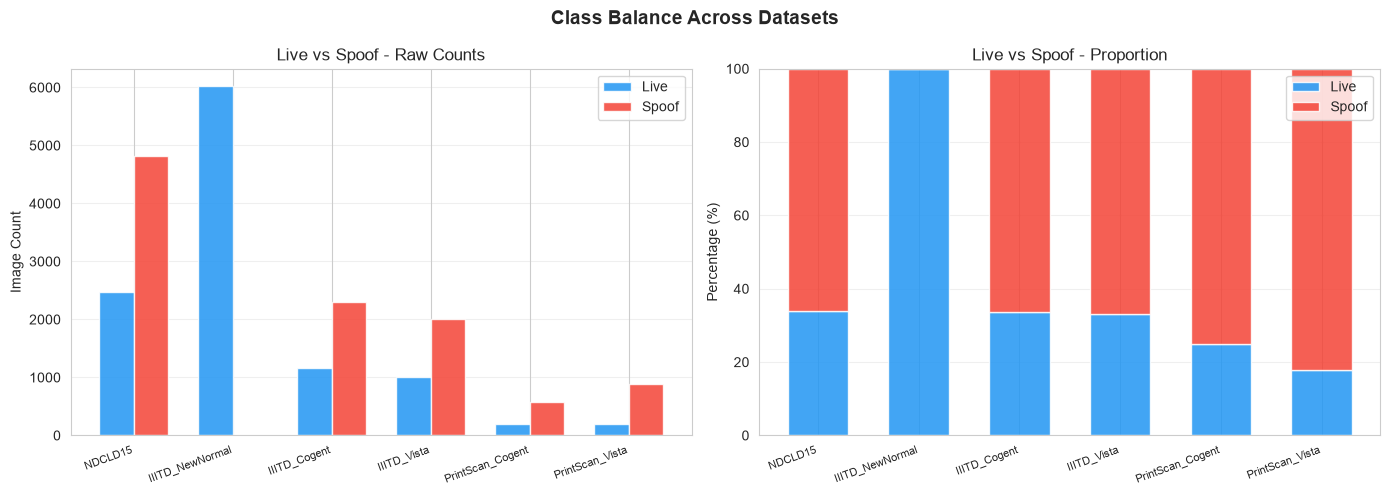

Saved → class_balance.png


In [19]:
# ---------------------------------------------------------------------------
# Left panel : raw Live vs Spoof counts per dataset, grouped bars.
# Right panel: same data as a 100%-stacked bar, to compare proportions
# directly regardless of each dataset's absolute size.
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Balance Across Datasets', fontsize=14, fontweight='bold')

x = np.arange(len(summary))
w = 0.35

axes[0].bar(x - w / 2, summary['Live'],  w, label='Live',  color='#2196F3', alpha=0.85)
axes[0].bar(x + w / 2, summary['Spoof'], w, label='Spoof', color='#F44336', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(summary['Dataset'], rotation=20, ha='right', fontsize=8)
axes[0].set_ylabel('Image Count')
axes[0].set_title('Live vs Spoof - Raw Counts')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

live_pct  = summary['Live']  / summary['Total'] * 100
spoof_pct = summary['Spoof'] / summary['Total'] * 100
axes[1].bar(x, live_pct,  width=0.6, label='Live',  color='#2196F3', alpha=0.85)
axes[1].bar(x, spoof_pct, width=0.6, bottom=live_pct, label='Spoof', color='#F44336', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(summary['Dataset'], rotation=20, ha='right', fontsize=8)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Live vs Spoof - Proportion')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SPLITS_DIR, 'class_balance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved \u2192 class_balance.png')


## 7. Image Resolution and Aspect Ratio

Different sensors and databases capture images at different native
resolutions (for example NDCLD15 vs. IIITD vs. PrintScan). The CNN in
Notebook 03 needs one single fixed input size, so this section samples a
handful of images per dataset to see the spread of native resolutions before
a resize target (224x224 / 256x256) is chosen.

A random sample of up to 60 images per dataset is read - sampling keeps this
fast across ~21k images while still being representative of each source.


Most common resolution per dataset (sampled):
         dataset most_common_(w,h)
    IIITD_Cogent        (640, 480)
 IIITD_NewNormal        (640, 480)
     IIITD_Vista        (640, 480)
         NDCLD15        (640, 480)
PrintScan_Cogent        (640, 480)
 PrintScan_Vista        (640, 480)

Aspect ratio statistics per dataset:
                     mean       std     min     max  count
dataset                                                   
IIITD_Cogent      1.33330  0.000000  1.3333  1.3333     60
IIITD_NewNormal   1.35275  0.065053  1.3333  1.5667     60
IIITD_Vista       1.33330  0.000000  1.3333  1.3333     60
NDCLD15           1.33330  0.000000  1.3333  1.3333     60
PrintScan_Cogent  1.33330  0.000000  1.3333  1.3333     60
PrintScan_Vista   1.33330  0.000000  1.3333  1.3333     60

⚠️  5 image(s) with a DIFFERENT aspect ratio than the rest:
        dataset  width  height  aspect_ratio
IIITD_NewNormal    752     480        1.5667
IIITD_NewNormal    752     480        1.5667
III

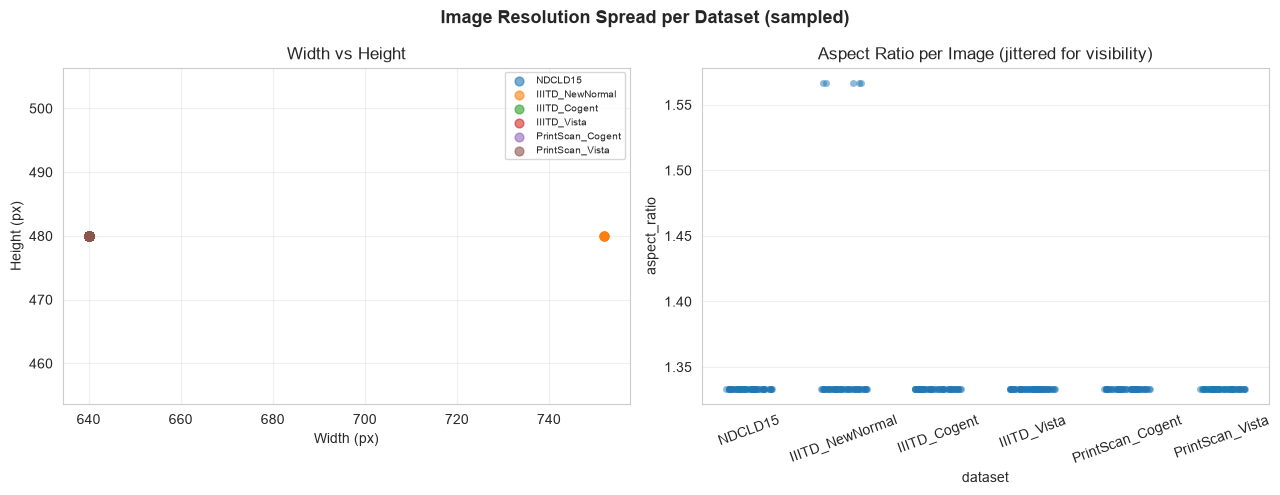


Saved → resolution_eda.png


In [20]:
# ---------------------------------------------------------------------------
# For each dataset, sample up to SAMPLE_N images, read their (width, height),
# and report the single most common resolution found in that sample.
# ---------------------------------------------------------------------------
SAMPLE_N = 60
rng = np.random.default_rng(42)  # fixed seed -> identical sample every run

res_rows = []
for ds in master_df['dataset'].unique():
    paths  = master_df[master_df.dataset == ds]['path'].tolist()
    sample = rng.choice(paths, size=min(SAMPLE_N, len(paths)), replace=False)
    for p in sample:
        img = cv2.imread(p, cv2.IMREAD_UNCHANGED)
        if img is None:
            continue
        h, w = img.shape[:2]
        res_rows.append({
            'dataset':      ds,
            'width':        w,
            'height':       h,
            'aspect_ratio': round(w / h, 4),
        })

res_df = pd.DataFrame(res_rows)

most_common = (
    res_df.groupby('dataset')
    .apply(lambda g: Counter(zip(g.width, g.height)).most_common(1)[0][0])
    .reset_index(name='most_common_(w,h)')
)
print("Most common resolution per dataset (sampled):")
print(most_common.to_string(index=False))

# ── Print exact aspect ratio stats per dataset (numeric, always visible) ──
print("\nAspect ratio statistics per dataset:")
ar_stats = res_df.groupby('dataset')['aspect_ratio'].agg(['mean','std','min','max','count'])
print(ar_stats.to_string())

# ── Flag any outlier rows explicitly (so they aren't just an invisible dot) ─
overall_mode = res_df['aspect_ratio'].mode()[0]
outliers = res_df[abs(res_df['aspect_ratio'] - overall_mode) > 0.01]
if len(outliers) > 0:
    print(f"\n⚠️  {len(outliers)} image(s) with a DIFFERENT aspect ratio than the rest:")
    print(outliers.to_string(index=False))
else:
    print(f"\n✅ All sampled images share the same aspect ratio ({overall_mode:.3f}) — no outliers.")

# ── Chart: since aspect ratio is nearly identical everywhere, a boxplot adds
#    nothing visible. Switch to width vs height scatter, which makes any
#    real difference between datasets immediately visible.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Image Resolution Spread per Dataset (sampled)', fontsize=13, fontweight='bold')

# Left: width vs height scatter, colored by dataset
for ds in res_df['dataset'].unique():
    sub = res_df[res_df['dataset'] == ds]
    axes[0].scatter(sub['width'], sub['height'], label=ds, alpha=0.6, s=40)
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Height (px)')
axes[0].set_title('Width vs Height')
axes[0].legend(fontsize=7, loc='best')
axes[0].grid(alpha=0.3)

# Right: aspect ratio as a strip/swarm plot (visible even with near-zero spread)
sns.stripplot(data=res_df, x='dataset', y='aspect_ratio', ax=axes[1],
              jitter=0.25, alpha=0.5, size=5)
axes[1].set_title('Aspect Ratio per Image (jittered for visibility)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SPLITS_DIR, 'resolution_eda.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved → resolution_eda.png')

## 8. Colour Mode - Grayscale vs RGB

Some sources (NDCLD15, PrintScan) are typically near-infrared / grayscale,
while IIITD images are often captured as 3-channel colour. This matters for
the CNN input pipeline in Notebook 02/03 - all images need to end up with a
consistent number of channels, either by converting colour images to
grayscale or by replicating grayscale images to 3 channels. The same
SAMPLE_N-image sample drawn in Section 7 is reused here for consistency.


In [11]:
# ---------------------------------------------------------------------------
# Re-use the same per-dataset sample (regenerated with the same seed) and
# classify each image as grayscale (single channel) or colour (3/4 channel).
# ---------------------------------------------------------------------------
color_rows = []
for ds in master_df['dataset'].unique():
    paths  = master_df[master_df.dataset == ds]['path'].tolist()
    sample = rng.choice(paths, size=min(SAMPLE_N, len(paths)), replace=False)
    n_gray, n_color = 0, 0
    for p in sample:
        img = cv2.imread(p, cv2.IMREAD_UNCHANGED)
        if img is None:
            continue
        if img.ndim == 2 or (img.ndim == 3 and img.shape[2] == 1):
            n_gray += 1
        else:
            n_color += 1
    color_rows.append({
        'dataset':          ds,
        'grayscale':        n_gray,
        'color(RGB/RGBA)':  n_color,
        'sampled':          n_gray + n_color,
    })

color_df = pd.DataFrame(color_rows)
print(color_df.to_string(index=False))
print("\nNOTE: Mixed grayscale/colour datasets will be normalised to a single "
      "channel convention in Notebook 02 before training.")


         dataset  grayscale  color(RGB/RGBA)  sampled
         NDCLD15          7               53       60
 IIITD_NewNormal         49               11       60
    IIITD_Cogent         60                0       60
     IIITD_Vista         60                0       60
PrintScan_Cogent          0               60       60
 PrintScan_Vista          0               60       60

NOTE: Mixed grayscale/colour datasets will be normalised to a single channel convention in Notebook 02 before training.


## 9. Sample Grids - Live vs Spoof

A direct visual side-by-side of 5 Live and 5 Spoof example images for every
dataset. This is the fastest way to sanity-check that the labelling rule for
each dataset (Section 3) is actually doing the right thing, rather than
trusting the per-dataset counts alone.


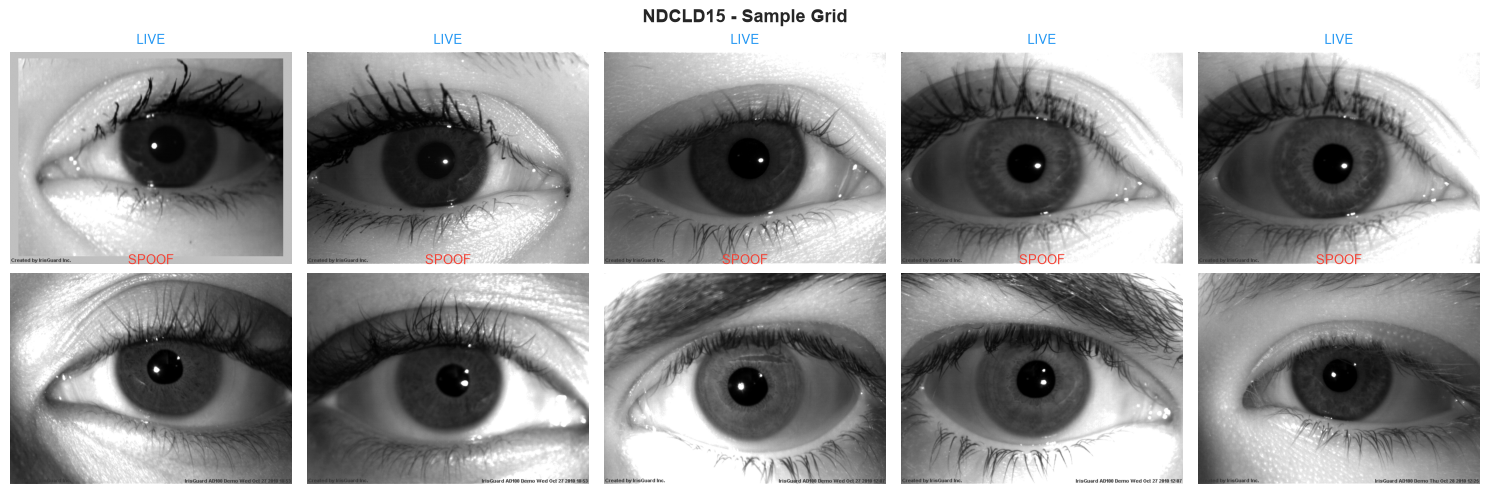

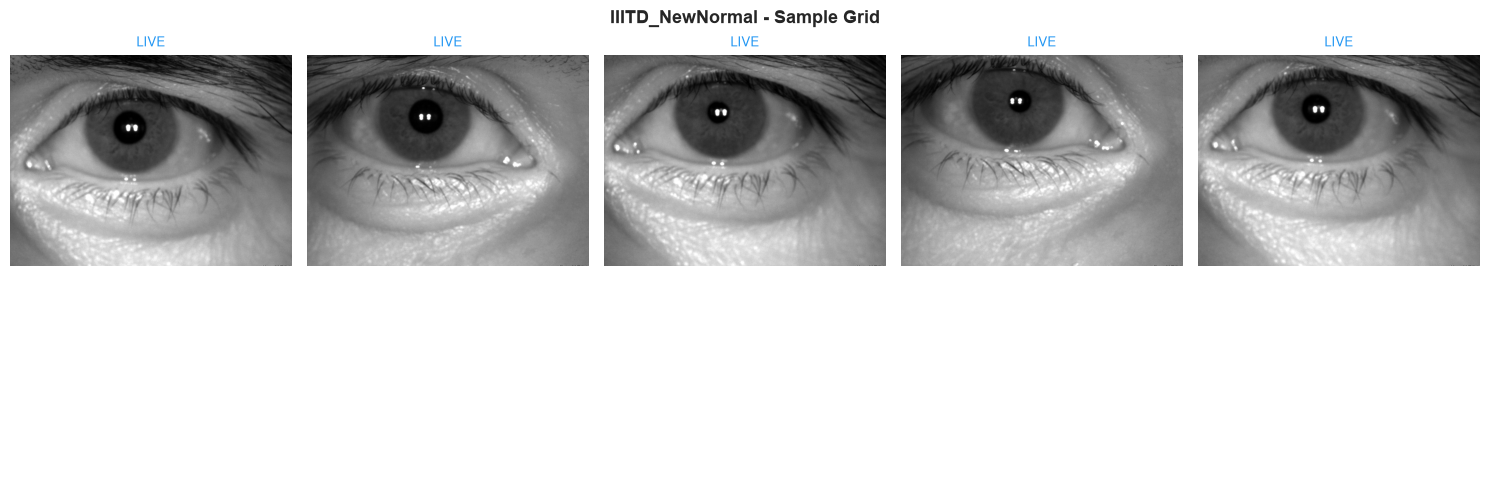

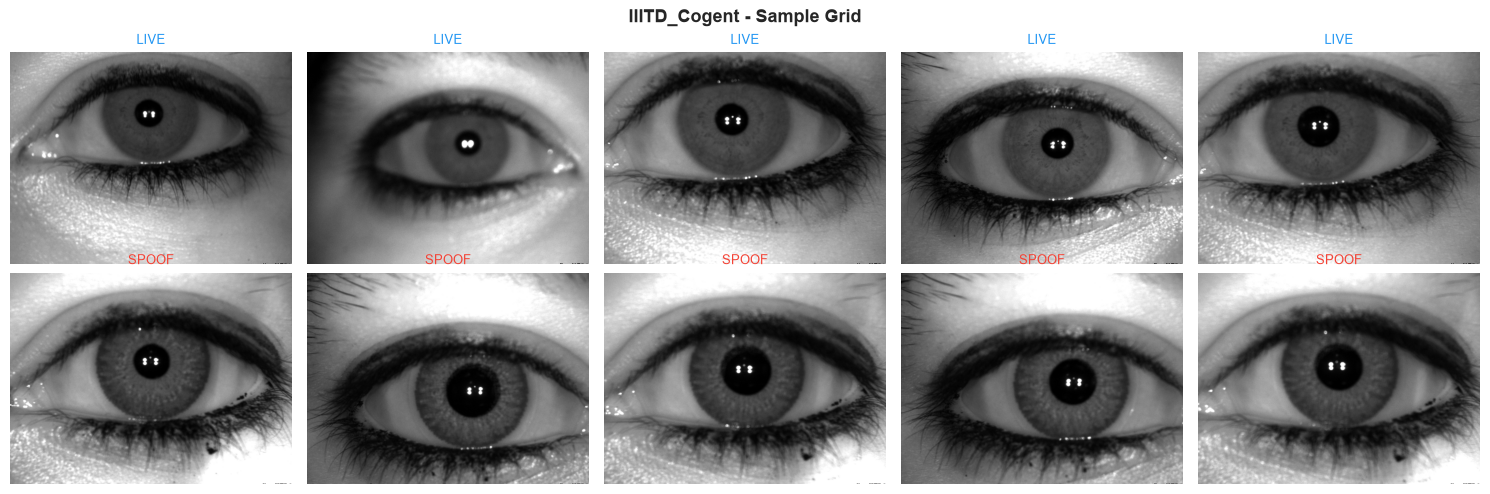

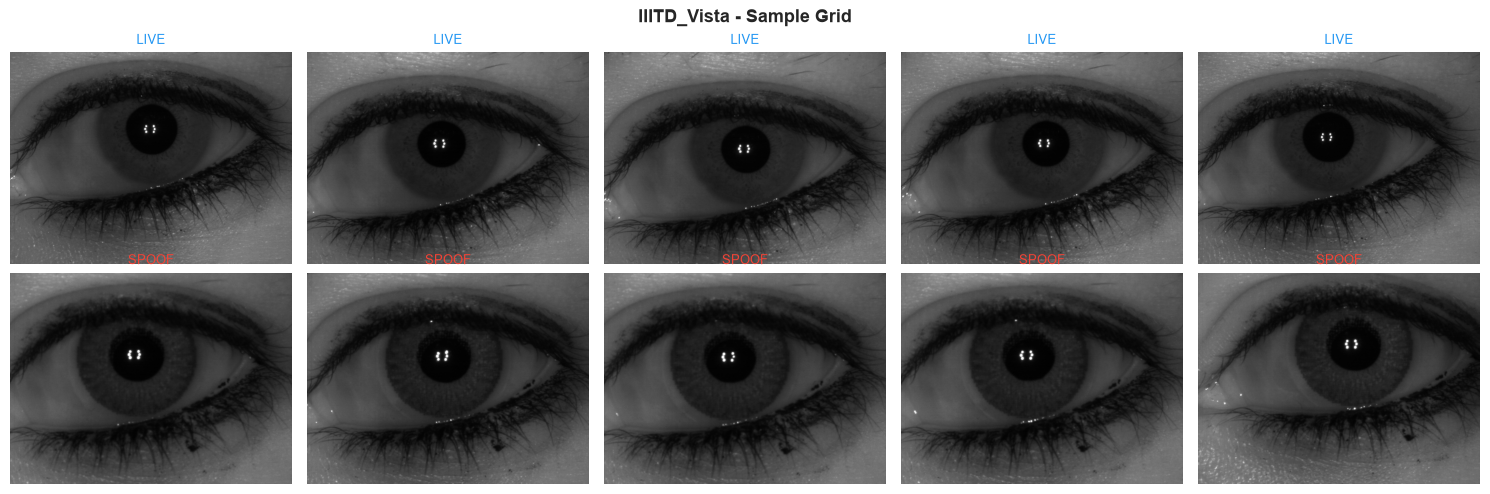

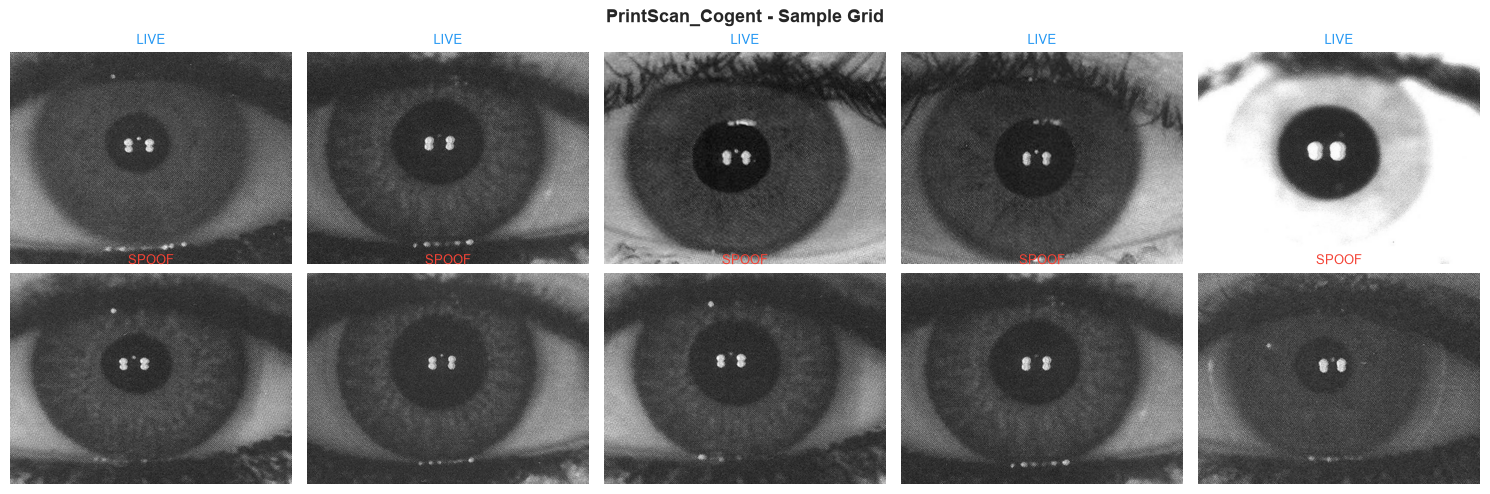

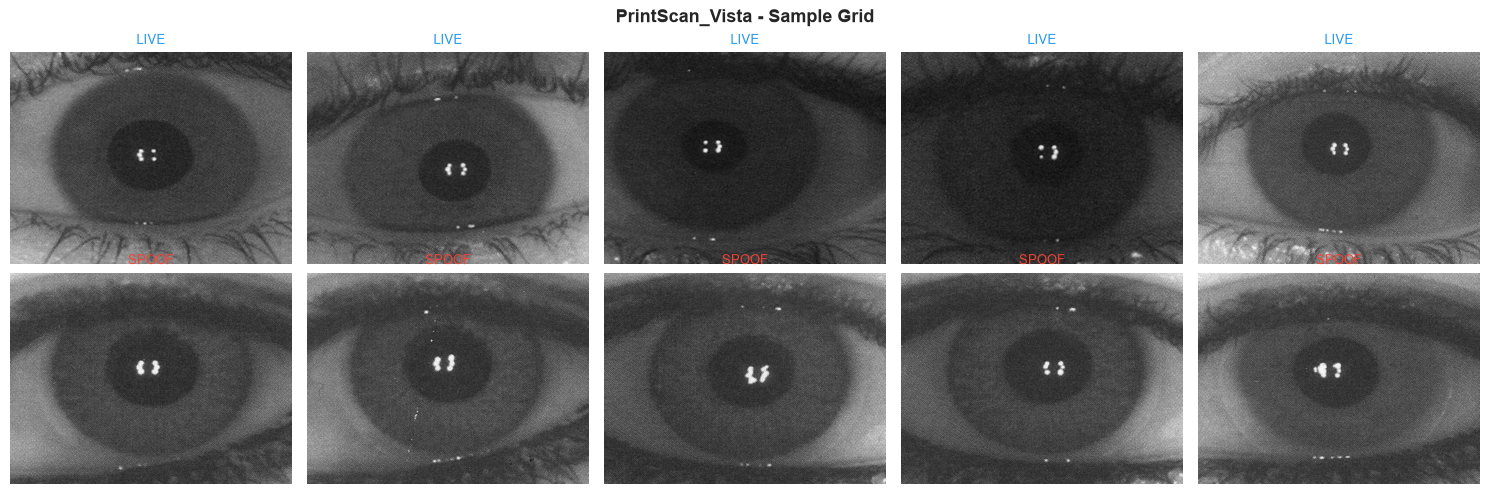

In [12]:
# ---------------------------------------------------------------------------
# load_gray() mirrors the same OpenCV-first, Pillow-fallback pattern used in
# the integrity check, so a file that is unreadable by one library but
# readable by the other still displays correctly here.
# ---------------------------------------------------------------------------
def load_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        try:
            img = np.array(PILImage.open(path).convert('L'))
        except Exception:
            return None
    return img

for ds in master_df['dataset'].unique():
    live_paths  = master_df[(master_df.dataset == ds) & (master_df.label == 0)]['path'].tolist()[:5]
    spoof_paths = master_df[(master_df.dataset == ds) & (master_df.label == 1)]['path'].tolist()[:5]
    if not live_paths and not spoof_paths:
        continue

    fig, axes = plt.subplots(2, 5, figsize=(15, 5))
    fig.suptitle(f'{ds} - Sample Grid', fontsize=13, fontweight='bold')
    for col in range(5):
        for row, (paths, lbl, color) in enumerate([
            (live_paths,  'LIVE',  '#2196F3'),
            (spoof_paths, 'SPOOF', '#F44336'),
        ]):
            ax = axes[row][col]
            if col < len(paths):
                img = load_gray(paths[col])
                if img is not None:
                    ax.imshow(img, cmap='gray')
                    ax.set_title(lbl, color=color, fontsize=9)
            ax.axis('off')
    plt.tight_layout()
    plt.show()


## 10. Pixel Statistics and Intensity Distributions

Mean / standard deviation of pixel intensity per dataset and label, plus an
overlaid histogram of pooled Live vs Spoof intensities across every dataset.
The purpose of this check is specifically to confirm the two classes are
**not** trivially separable by brightness alone - if Live images were simply
much brighter or darker than Spoof images on average, a CNN could learn that
shortcut instead of genuine presentation-attack cues, which would make the
final model fragile in deployment.


         Dataset Label   Mean   Std   Min    Max
         NDCLD15  live 133.96 73.36 60.59 207.32
         NDCLD15 spoof 139.40 64.93 74.48 204.33
 IIITD_NewNormal  live 125.24 58.18 67.07 183.42
    IIITD_Cogent  live 131.98 58.10 73.88 190.08
    IIITD_Cogent spoof 138.78 60.08 78.70 198.86
     IIITD_Vista  live  69.89 31.42 38.47 101.31
     IIITD_Vista spoof  70.41 32.75 37.66 103.15
PrintScan_Cogent  live 101.80 44.07 57.73 145.87
PrintScan_Cogent spoof  98.15 41.42 56.73 139.57
 PrintScan_Vista  live  95.76 35.01 60.75 130.78
 PrintScan_Vista spoof  98.39 37.13 61.26 135.52


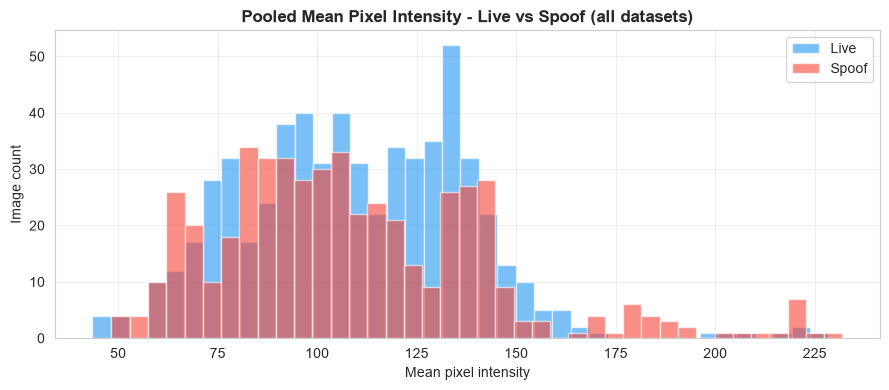

Saved → pixel_intensity_hist.png


In [13]:
# ---------------------------------------------------------------------------
# For each (dataset, label) pair, sample up to 100 images and compute the
# mean and standard deviation of pixel intensity. Pooled means across ALL
# datasets are also kept separately to drive the overlaid histogram below.
# ---------------------------------------------------------------------------
pixel_stats = []
all_means = {'live': [], 'spoof': []}

for ds in master_df['dataset'].unique():
    for lbl, lname in [(0, 'live'), (1, 'spoof')]:
        paths = master_df[(master_df.dataset == ds) & (master_df.label == lbl)]['path'].tolist()[:100]
        if not paths:
            continue
        means, stds = [], []
        for p in paths:
            img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            if img is None:
                try:
                    img = np.array(PILImage.open(p).convert('L'))
                except Exception:
                    continue
            means.append(img.mean())
            stds.append(img.std())
            all_means[lname].append(img.mean())
        if means:
            pixel_stats.append({
                'Dataset': ds, 'Label': lname,
                'Mean':  round(float(np.mean(means)), 2),
                'Std':   round(float(np.mean(stds)),  2),
                'Min':   round(float(np.mean(means)) - float(np.mean(stds)), 2),
                'Max':   round(float(np.mean(means)) + float(np.mean(stds)), 2),
            })

pixel_df = pd.DataFrame(pixel_stats)
print(pixel_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(all_means['live'],  bins=40, alpha=0.6, color='#2196F3', label='Live')
ax.hist(all_means['spoof'], bins=40, alpha=0.6, color='#F44336', label='Spoof')
ax.set_title('Pooled Mean Pixel Intensity - Live vs Spoof (all datasets)',
              fontsize=12, fontweight='bold')
ax.set_xlabel('Mean pixel intensity')
ax.set_ylabel('Image count')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SPLITS_DIR, 'pixel_intensity_hist.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved \u2192 pixel_intensity_hist.png')


## 11. Subject-Level Distribution (for Subject-Disjoint Splits)

To avoid identity leakage - the same eye/subject appearing in both the
training set and the test set - Notebook 02 must split data **per subject**,
not per individual image. This section checks how many unique subjects exist
per dataset/label, and whether any subject ID appears under both Live and
Spoof within the same dataset, so we know roughly how many subjects are
available to allocate across train/val/test, and whether any extra care is
needed for a particular dataset.

**Note on IIITD_NewNormal:** this dataset was collected with `os.walk` in
Section 3 using each image's *immediate parent folder name* as its subject
id. If every image in this dataset physically sits in one single folder (no
per-subject sub-folders on disk), every image will report 'root' as its
subject, which means this dataset cannot currently be split in a
subject-disjoint way and will need either a random split or, if individual
subject folders genuinely do not exist in the source download, must be
treated as one block when allocating train/val/test in Notebook 02.


In [14]:
# ---------------------------------------------------------------------------
# Per-dataset subject counts, split by label, plus a flag for any subject
# that appears in both Live and Spoof within the same dataset (such overlap
# would make a naive per-image split leak identity information across
# train/val/test).
# ---------------------------------------------------------------------------
subj_rows = []
for ds in master_df['dataset'].unique():
    sub = master_df[master_df.dataset == ds]
    subj_rows.append({
        'Dataset':            ds,
        'Unique Subjects':    sub['subject'].nunique(),
        'Live Subjects':      sub[sub.label == 0]['subject'].nunique(),
        'Spoof Subjects':     sub[sub.label == 1]['subject'].nunique(),
        'Avg Images/Subject': round(len(sub) / max(sub['subject'].nunique(), 1), 1),
    })
subj_df = pd.DataFrame(subj_rows)
print(subj_df.to_string(index=False))

# Flag the IIITD_NewNormal "single subject" situation explicitly so it is
# never missed when this notebook's output is reviewed later.
nn_row = subj_df[subj_df['Dataset'] == 'IIITD_NewNormal']
if not nn_row.empty and int(nn_row['Unique Subjects'].iloc[0]) <= 1:
    print("\n\u26a0\ufe0f  IIITD_NewNormal reports only 1 unique 'subject' value.")
    print("    This means every image in this dataset sat in the same top-level")
    print("    folder on disk (no per-subject sub-folders were found), so this")
    print("    dataset cannot be split in a subject-disjoint way as-is.")
    print("    Action needed in Notebook 02: either split this dataset randomly")
    print("    at the image level (acceptable since it is a Live-only reference")
    print("    set, not used for any Live/Spoof decision boundary), or confirm")
    print("    whether subject sub-folders exist deeper in the source download.")

print("\nSubjects appearing in BOTH Live and Spoof (within the same dataset):")
for ds in master_df['dataset'].unique():
    sub = master_df[master_df.dataset == ds]
    live_subj  = set(sub[sub.label == 0]['subject'])
    spoof_subj = set(sub[sub.label == 1]['subject'])
    overlap = live_subj & spoof_subj
    print(f"  {ds:18s}: {len(overlap)} overlapping subject IDs")


         Dataset  Unique Subjects  Live Subjects  Spoof Subjects  Avg Images/Subject
         NDCLD15              326            166             162                22.4
 IIITD_NewNormal                1              1               0              6022.0
    IIITD_Cogent              101            101             101                34.3
     IIITD_Vista              101            100             101                29.9
PrintScan_Cogent               97             97              97                 8.0
 PrintScan_Vista              101             96             101                10.7

⚠️  IIITD_NewNormal reports only 1 unique 'subject' value.
    This means every image in this dataset sat in the same top-level
    folder on disk (no per-subject sub-folders were found), so this
    dataset cannot be split in a subject-disjoint way as-is.
    Action needed in Notebook 02: either split this dataset randomly
    at the image level (acceptable since it is a Live-only reference
    set, 

## 12. Save -> master_index.csv

The final, cleaned, fully-labelled table is written once to
`Data/splits/master_index.csv`, alongside the per-dataset `dataset_summary.csv`
produced in Section 5. Every later notebook in this project reads from these
two files instead of re-scanning the raw folders, which keeps the labelling
logic in exactly one place.


In [17]:
# ---------------------------------------------------------------------------
# Persist the two output tables this notebook is responsible for producing.
# ---------------------------------------------------------------------------
master_csv  = os.path.join(SPLITS_DIR, 'master_index.csv')
summary_csv = os.path.join(SPLITS_DIR, 'dataset_summary.csv')

master_df.to_csv(master_csv,  index=False)
summary.to_csv(summary_csv,   index=False)


for _, row in summary.iterrows():
    print(f"  {row['Dataset']:22s} | Live:{row['Live']:5d} | Spoof:{row['Spoof']:5d} | Total:{row['Total']:5d}")
print('=' * 58)
print(f"  {'GRAND TOTAL':22s} | Live:{(master_df.label == 0).sum():5d} | "
      f"Spoof:{(master_df.label == 1).sum():5d} | Total:{len(master_df):5d}")
print('=' * 58)
print(f"\n\u2705 master_index.csv saved  \u2192 {master_csv}")
print(f"\u2705 dataset_summary.csv saved \u2192 {summary_csv}")



  NDCLD15                | Live: 2475 | Spoof: 4825 | Total: 7300
  IIITD_NewNormal        | Live: 6022 | Spoof:    0 | Total: 6022
  IIITD_Cogent           | Live: 1163 | Spoof: 2303 | Total: 3466
  IIITD_Vista            | Live: 1000 | Spoof: 2015 | Total: 3015
  PrintScan_Cogent       | Live:  194 | Spoof:  581 | Total:  775
  PrintScan_Vista        | Live:  192 | Spoof:  889 | Total: 1081
  GRAND TOTAL            | Live:11046 | Spoof:10613 | Total:21659

✅ master_index.csv saved  → C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\splits\master_index.csv
✅ dataset_summary.csv saved → C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\splits\dataset_summary.csv
